# 🫁 Phase 1.1v4: Enhanced Image Classifier — Single Split + TTA (PA Viewpoint)

### Features of this notebook:
1. **Single Patient-Level Split** (`GroupShuffleSplit` on `subject_id`) — fast training and zero patient leakage
2. **Test Time Augmentation (TTA)** — average predictions over 10 augmented versions of each test image
3. **Youden's J Threshold Calibration** — calibrated on the validation set to optimize recall and specificity
4. **DenseNet121 CXR-pretrained backbone** (`torchxrayvision`)
5. **CLAHE preprocessing + Lung ROI cropping**
6. **CBAM attention**
7. **Focal Loss (γ=2) + 2× pneumonia class weight**
8. **Mixup augmentation (α=0.3) + Label smoothing (0.1)**
9. **Safe augmentations only (no horizontal flip)**
10. **Differential learning rates**

In [1]:
# --- CELL 0: Imports & Reproducibility ---
import os, random, warnings, copy, json as json_lib
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score, auc,
    precision_recall_curve, average_precision_score
)

import torchxrayvision as xrv

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    print('Memory:', torch.cuda.get_device_properties(DEVICE).total_memory / 1e9, 'GB')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Memory: 4.294508544 GB


In [2]:
# --- CELL 1: Paths & Hyperparameters ---
BASE_DIR   = r'C:\2026\PneumoFusionNet\mimic\1000_dataset'
CSV_PATH   = os.path.join(BASE_DIR, 'mimic_paired_dataset.csv')
SAVE_DIR   = os.path.join(BASE_DIR, 'outputs', 'Phase_1.1v4_PA_single_split')
BBOX_CSV   = os.path.join(BASE_DIR, 'outputs', 'Phase_1.1v2_PA_enhanced', 'lung_bboxes.csv')
MODEL_PATH = os.path.join(SAVE_DIR, 'best_model.pth')

IMG_SIZE       = 224
BATCH_SIZE     = 8
NUM_EPOCHS     = 40
LR             = 3e-5
WEIGHT_DECAY   = 1e-4
NUM_CLASSES    = 2
WARMUP_EPOCHS  = 5
GRAD_CLIP      = 1.0
PATIENCE       = 12
MIXUP_ALPHA    = 0.3
LABEL_SMOOTH   = 0.1
PNEUMONIA_WT   = 2.0
TTA_TRANSFORMS = 10  # Number of augmented views for TTA

CLASSES = ['NORMAL', 'PNEUMONIA']
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save dir    : {SAVE_DIR}')
print(f'TTA views   : {TTA_TRANSFORMS}')
print(f'Epochs      : {NUM_EPOCHS}')

Save dir    : C:\2026\PneumoFusionNet\mimic\1000_dataset\outputs\Phase_1.1v4_PA_single_split
TTA views   : 10
Epochs      : 40


In [3]:
# --- CELL 2: Data Loading & Filtering ---
df = pd.read_csv(CSV_PATH)

def resolve_data_path(path):
    if pd.isna(path) or str(path).strip() == '':
        return ''
    path = str(path).replace('/', os.sep).replace('\\', os.sep)
    return path if os.path.isabs(path) else os.path.join(BASE_DIR, path)

df['image_path'] = df['image_path'].apply(resolve_data_path)
df['label'] = np.select(
    [df['pneumonia_label'].eq(1.0), df['no_finding_label'].eq(1.0)],
    [1, 0], default=-1
)
df = df[(df['label'] >= 0) & df['view_position'].eq('PA')].copy()
df['label_name'] = df['label'].map({0: 'Normal', 1: 'Pneumonia'})

# Balance
n_per_class = int(df['label'].value_counts().min())
normal_df    = df[df['label'] == 0].sample(n=n_per_class, random_state=SEED)
pneumonia_df = df[df['label'] == 1].sample(n=n_per_class, random_state=SEED)
df = pd.concat([normal_df, pneumonia_df]).sample(frac=1, random_state=SEED).reset_index(drop=True)

missing = df['image_path'].apply(lambda p: not os.path.exists(p)).sum()
print(f'Total: {len(df)} | Per class: {n_per_class} | Missing: {missing}')

Total: 1854 | Per class: 927 | Missing: 0


In [4]:
# --- CELL 3: Lung Bounding Boxes ---
BBOX_CSV_V4 = os.path.join(SAVE_DIR, 'lung_bboxes.csv')
if os.path.exists(BBOX_CSV):
    bbox_df = pd.read_csv(BBOX_CSV)
    print(f'Reusing bboxes: {BBOX_CSV}')
elif os.path.exists(BBOX_CSV_V4):
    bbox_df = pd.read_csv(BBOX_CSV_V4)
    print(f'Reusing bboxes: {BBOX_CSV_V4}')
else:
    # Define bbox function
    def compute_lung_bbox(image_path, margin=10):
        try:
            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            if img is None: return None
            h, w = img.shape
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            img_eq = clahe.apply(img)
            blurred = cv2.GaussianBlur(img_eq, (5, 5), 0)
            _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if not contours: return None
            min_area = h * w * 0.05
            lung_contours = [c for c in contours if cv2.contourArea(c) > min_area]
            if not lung_contours:
                cx, cy = w // 2, h // 2
                crop_w, crop_h = int(w * 0.8), int(h * 0.8)
                return (cx - crop_w//2, cy - crop_h//2, cx + crop_w//2, cy + crop_h//2)
            all_points = np.vstack(lung_contours)
            x, y, bw, bh = cv2.boundingRect(all_points)
            return (max(0, x-margin), max(0, y-margin), min(w, x+bw+margin), min(h, y+bh+margin))
        except: return None
        
    print('Computing lung bounding boxes...')
    records = []
    for _, row in df.iterrows():
        bbox = compute_lung_bbox(row['image_path'])
        if bbox:
            records.append({'image_path': row['image_path'], 'x_min': bbox[0], 'y_min': bbox[1], 'x_max': bbox[2], 'y_max': bbox[3]})
        else:
            records.append({'image_path': row['image_path'], 'x_min': 0, 'y_min': 0, 'x_max': -1, 'y_max': -1})
    bbox_df = pd.DataFrame(records)
    bbox_df.to_csv(BBOX_CSV_V4, index=False)

bbox_lookup = bbox_df.set_index('image_path').to_dict('index')
print(f'Bboxes loaded: {len(bbox_lookup)}')

Reusing bboxes: C:\2026\PneumoFusionNet\mimic\1000_dataset\outputs\Phase_1.1v2_PA_enhanced\lung_bboxes.csv
Bboxes loaded: 354


In [5]:
# --- CELL 4: Compute Normalization Stats ---
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
means, stds = [], []
for idx in range(min(len(df), 200)):
    try:
        img = cv2.imread(df.iloc[idx]['image_path'], cv2.IMREAD_GRAYSCALE)
        img = clahe.apply(img)
        bb = bbox_lookup.get(df.iloc[idx]['image_path'], None)
        if bb and bb['x_max'] > 0:
            img = img[bb['y_min']:bb['y_max'], bb['x_min']:bb['x_max']]
        img_arr = np.array(img, dtype=np.float32) / 255.0
        means.append(img_arr.mean())
        stds.append(img_arr.std())
    except: continue
MEAN = [np.mean(means)]
STD  = [np.mean(stds)]
print(f'MEAN: {MEAN[0]:.4f} | STD: {STD[0]:.4f}')

MEAN: 0.5007 | STD: 0.2732


In [6]:
# --- CELL 5: Transforms (Train / Val / TTA) ---
train_tfm = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08)),
])

val_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

tta_transforms = [
    val_tfm,  # 0: Original
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomRotation((5, 5)), transforms.ToTensor(), transforms.Normalize(mean=MEAN, std=STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomRotation((-5, -5)), transforms.ToTensor(), transforms.Normalize(mean=MEAN, std=STD)]),
    transforms.Compose([transforms.Resize((256, 256)), transforms.CenterCrop(210), transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize(mean=MEAN, std=STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ColorJitter(brightness=0.15), transforms.ToTensor(), transforms.Normalize(mean=MEAN, std=STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ColorJitter(contrast=0.15), transforms.ToTensor(), transforms.Normalize(mean=MEAN, std=STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomAffine(degrees=0, translate=(0.03, 0.03)), transforms.ToTensor(), transforms.Normalize(mean=MEAN, std=STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomRotation((3, 3)), transforms.ToTensor(), transforms.Normalize(mean=MEAN, std=STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomRotation((-3, -3)), transforms.ToTensor(), transforms.Normalize(mean=MEAN, std=STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.GaussianBlur(kernel_size=3, sigma=(0.3, 0.5)), transforms.ToTensor(), transforms.Normalize(mean=MEAN, std=STD)]),
]
print(f'Train transform: safe augmentations (no hflip) | TTA transforms: {len(tta_transforms)} views')

Train transform: safe augmentations (no hflip) | TTA transforms: 10 views


In [7]:
# --- CELL 6: Dataset Class ---
class EnhancedCXRDataset(Dataset):
    def __init__(self, df, bbox_lookup, transform=None):
        self.df = df.reset_index(drop=True)
        self.bbox_lookup = bbox_lookup
        self.transform = transform
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row.image_path, cv2.IMREAD_GRAYSCALE)
        img = self.clahe.apply(img)
        bb = self.bbox_lookup.get(row.image_path, None)
        if bb and bb['x_max'] > 0:
            img = img[bb['y_min']:bb['y_max'], bb['x_min']:bb['x_max']]
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, int(row.label)

    def set_transform(self, transform):
        self.transform = transform
print('EnhancedCXRDataset defined.')

EnhancedCXRDataset defined.


In [8]:
# --- CELL 7: Patient-Level Single Split (70/15/15) ---
# First split out train (70%) and temp (30%)
gss_temp = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(gss_temp.split(df, df['label'].values, df['subject_id'].values))
train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df  = df.iloc[temp_idx].reset_index(drop=True)

# Split temp into val (50%) and test (50%) -> 15% and 15% of total
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(gss_val.split(temp_df, temp_df['label'].values, temp_df['subject_id'].values))
val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print('='*60)
print('DATASET SPLIT SUMMARY (Zero Patient Leakage)')
print('='*60)
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    n_total    = len(split_df)
    n_pneumonia = split_df['label'].sum()
    n_normal   = (split_df['label'] == 0).sum()
    print(f'{split_name:6s} | Total: {n_total:3d} | Normal: {n_normal:3d} | Pneumonia: {n_pneumonia:3d} | Patients: {split_df["subject_id"].nunique()}')
print('='*60)

DATASET SPLIT SUMMARY (Zero Patient Leakage)
Train  | Total: 1290 | Normal: 649 | Pneumonia: 641 | Patients: 1204
Val    | Total: 284 | Normal: 138 | Pneumonia: 146 | Patients: 258
Test   | Total: 280 | Normal: 140 | Pneumonia: 140 | Patients: 259


In [9]:
# --- CELL 8: CBAM + Focal Loss + Mixup ---
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return x * self.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out = x.max(dim=1, keepdim=True)[0]
        return x * self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_att = ChannelAttention(channels, reduction)
        self.spatial_att = SpatialAttention()
    def forward(self, x):
        return self.spatial_att(self.channel_att(x))

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma; self.label_smoothing = label_smoothing
    def forward(self, logits, targets):
        num_classes = logits.shape[1]
        if self.label_smoothing > 0:
            smooth = torch.zeros_like(logits).fill_(self.label_smoothing / (num_classes - 1))
            smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)
        else:
            smooth = F.one_hot(targets, num_classes).float()
        log_probs = F.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)
        focal_weight = (1.0 - probs) ** self.gamma
        loss = -focal_weight * smooth * log_probs
        if self.alpha is not None:
            loss = loss * self.alpha.to(logits.device).unsqueeze(0)
        return loss.sum(dim=1).mean()

def mixup_data(x, y, alpha=0.3):
    lam = max(np.random.beta(alpha, alpha), 1 - np.random.beta(alpha, alpha)) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[index], y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print('Helper functions & classes defined.')

Helper functions & classes defined.


In [10]:
# --- CELL 9: Model Factory ---
def build_model():
    class EnhancedPneumoNetV4(nn.Module):
        def __init__(self):
            super().__init__()
            xrv_model = xrv.models.DenseNet(weights='densenet121-res224-all')
            self.features = xrv_model.features
            freeze_layers = {'conv0','norm0','relu0','pool0','denseblock1','transition1','denseblock2','transition2'}
            for name, child in self.features.named_children():
                for p in child.parameters():
                    p.requires_grad = name not in freeze_layers
            self.cbam = CBAM(1024, reduction=16)
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.classifier = nn.Sequential(
                nn.Dropout(0.5), nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
                nn.Dropout(0.3), nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True),
                nn.Dropout(0.2), nn.Linear(128, NUM_CLASSES)
            )
        def forward(self, x):
            f = F.relu(self.features(x), inplace=True)
            f = self.cbam(f)
            f = self.pool(f).flatten(1)
            return self.classifier(f)
        def get_features(self, x):
            f = F.relu(self.features(x), inplace=True)
            f = self.cbam(f)
            return self.pool(f).flatten(1)

    model = EnhancedPneumoNetV4().to(DEVICE)
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Params: {total:,} total, {trainable:,} trainable ({trainable/total*100:.1f}%)')
    return model
print('Model factory ready.')

Model factory ready.


In [11]:
# --- CELL 10: Training + Evaluation Functions ---
def train_one_epoch(model, loader, criterion, optimizer, device, mixup_alpha):
    model.train()
    total_loss = total_correct = total_n = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        mixed, ya, yb, lam = mixup_data(imgs, labels, mixup_alpha)
        optimizer.zero_grad()
        out = model(mixed)
        loss = mixup_criterion(criterion, out, ya, yb, lam)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()
        total_loss += loss.item() * len(labels)
        preds = out.argmax(1)
        total_correct += (lam * (preds == ya).float().sum().item() +
                          (1 - lam) * (preds == yb).float().sum().item())
        total_n += len(labels)
    return total_loss / total_n, total_correct / total_n

def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            out = model(imgs)
            probs = F.softmax(out, dim=1)[:, 1]
            all_preds.extend(out.argmax(1).cpu().tolist())
            all_labels.extend(labels.tolist())
            all_probs.extend(probs.cpu().tolist())
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    try: auc_val = roc_auc_score(all_labels, all_probs)
    except: auc_val = 0.0
    return acc, auc_val, f1, all_preds, all_labels, all_probs

def evaluate_tta(model, dataset, tta_tfms, device, batch_size=8):
    model.eval()
    n_samples = len(dataset)
    n_views = len(tta_tfms)
    all_probs = np.zeros((n_samples, n_views))
    all_labels = []

    for v, tfm in enumerate(tta_tfms):
        dataset.set_transform(tfm)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        probs_v = []
        labels_v = []
        with torch.no_grad():
            for imgs, labels in loader:
                out = model(imgs.to(device))
                p = F.softmax(out, dim=1)[:, 1].cpu().numpy()
                probs_v.extend(p)
                labels_v.extend(labels.tolist())
        all_probs[:, v] = probs_v
        if v == 0:
            all_labels = labels_v

    avg_probs = all_probs.mean(axis=1)
    avg_preds = (avg_probs >= 0.5).astype(int)

    acc = accuracy_score(all_labels, avg_preds)
    f1  = f1_score(all_labels, avg_preds, average='macro')
    try: auc_val = roc_auc_score(all_labels, avg_probs)
    except: auc_val = 0.0
    return acc, auc_val, f1, avg_preds.tolist(), all_labels, avg_probs.tolist()

def find_optimal_threshold(labels, probs):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    youden_j = tpr - fpr
    idx = np.argmax(youden_j)
    return thresholds[idx]

print('Functions ready.')

Functions ready.


In [12]:
# --- CELL 11: Single Split Training Loop with Auto-Resume ---
import time
import os

# Dataloaders
tr_labels = train_df['label'].values
cls_counts = np.bincount(tr_labels)
sw = [1.0 / cls_counts[l] for l in tr_labels]
sampler = WeightedRandomSampler(sw, len(sw), replacement=True)

train_loader = DataLoader(EnhancedCXRDataset(train_df, bbox_lookup, train_tfm),
                          batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, drop_last=True)
val_loader   = DataLoader(EnhancedCXRDataset(val_df, bbox_lookup, val_tfm),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_dataset = EnhancedCXRDataset(test_df, bbox_lookup, val_tfm)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
val_dataset  = EnhancedCXRDataset(val_df, bbox_lookup, val_tfm)

model = build_model()
class_weights = torch.tensor([1.0, PNEUMONIA_WT], dtype=torch.float32)
criterion = FocalLoss(alpha=class_weights, gamma=2.0, label_smoothing=LABEL_SMOOTH)

pretrained_params = [p for n, p in model.named_parameters() if p.requires_grad and 'classifier' not in n and 'cbam' not in n]
new_params = [p for n, p in model.named_parameters() if p.requires_grad and ('classifier' in n or 'cbam' in n)]
optimizer = optim.AdamW([
    {'params': pretrained_params, 'lr': LR},
    {'params': new_params, 'lr': LR * 10},
], weight_decay=WEIGHT_DECAY)

warmup = LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-7)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[WARMUP_EPOCHS])

# Checkpoint paths
checkpoint_path = os.path.join(SAVE_DIR, 'latest_checkpoint.pth')
start_epoch = 0
best_auc = 0.0
best_epoch = 0
patience_ctr = 0
epoch_times = []

# --- AUTO-RESUME LOGIC ---
if os.path.exists(checkpoint_path):
    print('='*80)
    print(f'RESUMING TRAINING FROM CHECKPOINT: {checkpoint_path}')
    print('='*80)
    try:
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_auc = checkpoint['best_auc']
        best_epoch = checkpoint['best_epoch']
        patience_ctr = checkpoint['patience_ctr']
        epoch_times = checkpoint.get('epoch_times', [])
        print(f'Resumed successfully. Starting from Epoch {start_epoch+1} (Best Val AUC: {best_auc:.4f})')
    except Exception as e:
        print(f'Failed to load checkpoint ({e}). Starting training from scratch.')
        start_epoch = 0
else:
    print('='*80)
    print('TRAINING STARTED (Single Split from scratch)')
    print('='*80)

for epoch in range(start_epoch, NUM_EPOCHS):
    start_time = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, MIXUP_ALPHA)
    scheduler.step()
    va_acc, va_auc, va_f1, _, _, _ = evaluate(model, val_loader, DEVICE)
    
    elapsed = time.time() - start_time
    epoch_times.append(elapsed)
    mean_epoch_time = np.mean(epoch_times)
    remaining_epochs = NUM_EPOCHS - (epoch + 1)
    eta_sec = int(remaining_epochs * mean_epoch_time)
    
    improved = False
    if va_auc > best_auc:
        best_auc = va_auc; best_epoch = epoch; patience_ctr = 0
        torch.save(model.state_dict(), MODEL_PATH)
        improved = True
    else:
        patience_ctr += 1
        
    # Save checkpoint at the end of every epoch
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_auc': best_auc,
        'best_epoch': best_epoch,
        'patience_ctr': patience_ctr,
        'epoch_times': epoch_times
    }, checkpoint_path)
        
    if (epoch + 1) % 5 == 0 or epoch == 0 or improved:
        mark = ' *' if improved else ''
        time_str = f'[{int(elapsed)}s/epoch | ETA: {eta_sec//60}m {eta_sec%60}s]'
        print(f'  Epoch {epoch+1:02d}/{NUM_EPOCHS} | TrainLoss: {tr_loss:.4f} ({tr_acc:.3f}) | ValLoss: {1.0-va_acc:.4f} ({va_acc:.3f}) | ValAUC: {va_auc:.4f}{mark} {time_str}')
        
    if patience_ctr >= PATIENCE:
        print(f'  Early stopping at epoch {epoch+1}')
        break

# Clean up latest checkpoint on successful completion
if os.path.exists(checkpoint_path) and patience_ctr >= PATIENCE or epoch == NUM_EPOCHS - 1:
    try:
        os.remove(checkpoint_path)
        print("Training fully complete. Cleaned up latest checkpoint.")
    except:
        pass

print('='*80)
print(f'TRAINING COMPLETE | Best Val AUC: {best_auc:.4f} at Epoch {best_epoch+1}')
print('='*80)


  Params: 7,670,756 total, 6,247,396 trainable (81.4%)
TRAINING STARTED (Single Split)
  Epoch 01/40 | TrainLoss: 0.3435 (0.539) | ValLoss: 0.2641 (0.736) | ValAUC: 0.8136 * [146s/epoch | ETA: 95m 28s]
  Epoch 02/40 | TrainLoss: 0.3052 (0.576) | ValLoss: 0.2641 (0.736) | ValAUC: 0.8188 * [136s/epoch | ETA: 89m 44s]
  Epoch 03/40 | TrainLoss: 0.2829 (0.599) | ValLoss: 0.2570 (0.743) | ValAUC: 0.8272 * [147s/epoch | ETA: 88m 34s]
  Epoch 04/40 | TrainLoss: 0.2686 (0.602) | ValLoss: 0.2641 (0.736) | ValAUC: 0.8336 * [134s/epoch | ETA: 84m 46s]
  Epoch 05/40 | TrainLoss: 0.2624 (0.582) | ValLoss: 0.3662 (0.634) | ValAUC: 0.7450 [281s/epoch | ETA: 98m 47s]
  Epoch 06/40 | TrainLoss: 0.2519 (0.581) | ValLoss: 0.2958 (0.704) | ValAUC: 0.8352 * [250s/epoch | ETA: 103m 39s]
  Epoch 10/40 | TrainLoss: 0.2306 (0.599) | ValLoss: 0.2394 (0.761) | ValAUC: 0.8538 * [168s/epoch | ETA: 101m 57s]
  Epoch 12/40 | TrainLoss: 0.2256 (0.596) | ValLoss: 0.2817 (0.718) | ValAUC: 0.8584 * [213s/epoch | ETA: 95

In [15]:
a=1
print('Training loop finished. Ready for final evaluation.')

Training loop finished. Ready for final evaluation.


In [17]:
# --- Debugging Cell 12 ---
def evaluate_tta_debug(model, dataset, tta_tfms, device, batch_size=8):
    model.eval()
    n_samples = len(dataset)
    n_views = len(tta_tfms)
    all_probs = np.zeros((n_samples, n_views))
    all_labels = []

    print(f"Starting TTA on {n_samples} samples across {n_views} views...")
    for v, tfm in enumerate(tta_tfms):
        print(f"  Running view {v+1}/{n_views}...", end="", flush=True)
        dataset.set_transform(tfm)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        probs_v = []
        labels_v = []
        with torch.no_grad():
            for imgs, labels in loader:
                out = model(imgs.to(device))
                p = F.softmax(out, dim=1)[:, 1].cpu().numpy()
                probs_v.extend(p)
                labels_v.extend(labels.tolist())
        all_probs[:, v] = probs_v
        if v == 0:
            all_labels = labels_v
        print(" Done!")

    avg_probs = all_probs.mean(axis=1)
    avg_preds = (avg_probs >= 0.5).astype(int)
    acc = accuracy_score(all_labels, avg_preds)
    f1  = f1_score(all_labels, avg_preds, average='macro')
    try: auc_val = roc_auc_score(all_labels, avg_probs)
    except: auc_val = 0.0
    return acc, auc_val, f1, avg_preds.tolist(), all_labels, avg_probs.tolist()

# Replace evaluate_tta with our debug version
evaluate_tta = evaluate_tta_debug
print("Debug evaluate_tta function registered.")

Debug evaluate_tta function registered.


In [18]:
# --- CELL 12: Inference & Calibration on Validation/Test Set ---
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

# Standard Evaluation on Test
te_acc, te_auc, te_f1, te_preds, te_labels, te_probs = evaluate(model, test_loader, DEVICE)

# TTA Evaluation on Val (to calibrate threshold without test leakage)
_, _, _, _, val_labels_tta, val_probs_tta = evaluate_tta(model, val_dataset, tta_transforms, DEVICE, BATCH_SIZE)
opt_thresh = find_optimal_threshold(val_labels_tta, val_probs_tta)

# TTA Evaluation on Test
te_acc_tta, te_auc_tta, te_f1_tta, te_preds_tta, te_labels_tta, te_probs_tta = evaluate_tta(
    model, test_dataset, tta_transforms, DEVICE, BATCH_SIZE
)

# Apply validation-calibrated threshold to Test
te_preds_tuned = [1 if p >= opt_thresh else 0 for p in te_probs_tta]
te_acc_tuned = accuracy_score(te_labels_tta, te_preds_tuned)
te_f1_tuned  = f1_score(te_labels_tta, te_preds_tuned, average='macro')

print('='*60)
print('FINAL TEST SET RESULTS')
print('='*60)
print(f'Standard Model : Acc={te_acc:.4f} AUC={te_auc:.4f} F1={te_f1:.4f}')
print(f'TTA Model (0.5): Acc={te_acc_tta:.4f} AUC={te_auc_tta:.4f} F1={te_f1_tta:.4f}')
print(f'TTA + Tuned    : Acc={te_acc_tuned:.4f} F1={te_f1_tuned:.4f} (calibrated threshold={opt_thresh:.4f})')

cm = confusion_matrix(te_labels_tta, te_preds_tuned)
if cm.shape == (2, 2):
    pn_recall = cm[1,1] / (cm[1,0]+cm[1,1]) if (cm[1,0]+cm[1,1])>0 else 0
    pn_spec   = cm[0,0] / (cm[0,0]+cm[0,1]) if (cm[0,0]+cm[0,1])>0 else 0
    print(f'Pneumonia Recall: {pn_recall:.1%} | Specificity: {pn_spec:.1%}')
print('='*60)

Starting TTA on 284 samples across 10 views...
  Running view 1/10... Done!
  Running view 2/10... Done!
  Running view 3/10... Done!
  Running view 4/10... Done!
  Running view 5/10... Done!
  Running view 6/10... Done!
  Running view 7/10... Done!
  Running view 8/10... Done!
  Running view 9/10... Done!
  Running view 10/10... Done!
Starting TTA on 280 samples across 10 views...
  Running view 1/10... Done!
  Running view 2/10... Done!
  Running view 3/10... Done!
  Running view 4/10... Done!
  Running view 5/10... Done!
  Running view 6/10... Done!
  Running view 7/10... Done!
  Running view 8/10... Done!
  Running view 9/10... Done!
  Running view 10/10... Done!
FINAL TEST SET RESULTS
Standard Model : Acc=0.7250 AUC=0.8637 F1=0.7163
TTA Model (0.5): Acc=0.6857 AUC=0.8639 F1=0.6695
TTA + Tuned    : Acc=0.7821 F1=0.7820 (calibrated threshold=0.5456)
Pneumonia Recall: 80.7% | Specificity: 75.7%


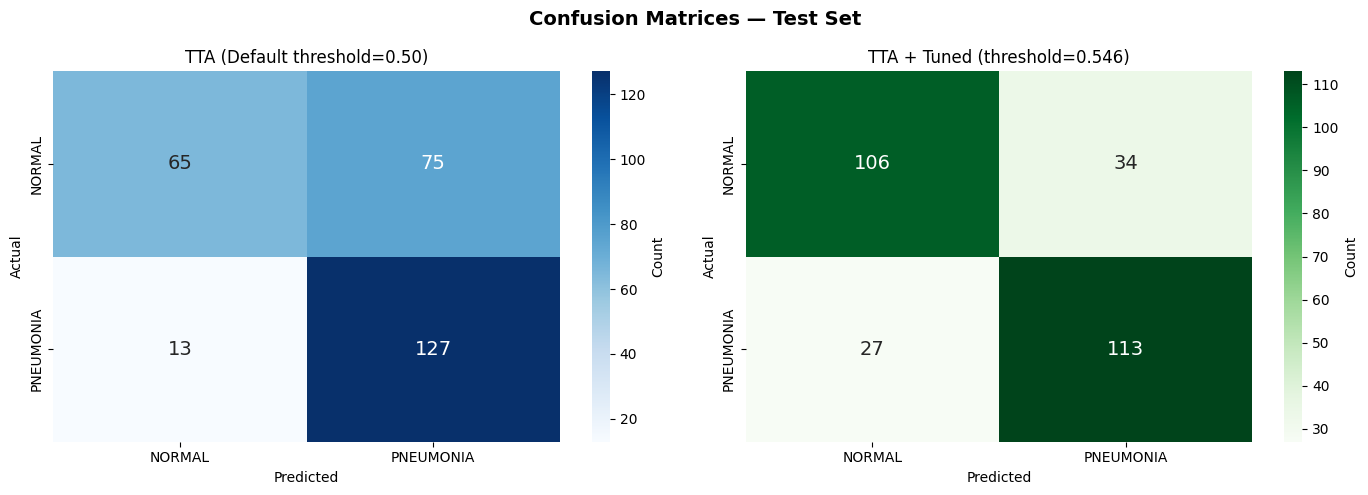

Classification Report (Default TTA threshold=0.50):
              precision    recall  f1-score   support

      NORMAL       0.83      0.46      0.60       140
   PNEUMONIA       0.63      0.91      0.74       140

    accuracy                           0.69       280
   macro avg       0.73      0.69      0.67       280
weighted avg       0.73      0.69      0.67       280

Classification Report (Tuned TTA threshold=0.546):
              precision    recall  f1-score   support

      NORMAL       0.80      0.76      0.78       140
   PNEUMONIA       0.77      0.81      0.79       140

    accuracy                           0.78       280
   macro avg       0.78      0.78      0.78       280
weighted avg       0.78      0.78      0.78       280



In [19]:
# --- CELL 13: Confusion Matrices & ROC Curves ---
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')

# TTA (0.50)
cm_tta = confusion_matrix(te_labels_tta, te_preds_tta)
sns.heatmap(cm_tta, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0],
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14})
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('TTA (Default threshold=0.50)')

# TTA + Tuned
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1],
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14})
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_title(f'TTA + Tuned (threshold={opt_thresh:.3f})')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

# Classification Reports
print('Classification Report (Default TTA threshold=0.50):')
print(classification_report(te_labels_tta, te_preds_tta, target_names=CLASSES))
print(f'Classification Report (Tuned TTA threshold={opt_thresh:.3f}):')
print(classification_report(te_labels_tta, te_preds_tuned, target_names=CLASSES))

In [20]:
# --- CELL 14: Save Final Features & Config ---
print('Extracting and saving image features split-wise...')
model.eval()

for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    split_loader = DataLoader(EnhancedCXRDataset(split_df, bbox_lookup, val_tfm), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    feats = []
    labs  = []
    with torch.no_grad():
        for imgs, labels in split_loader:
            feat = model.get_features(imgs.to(DEVICE)).cpu()
            feats.append(feat)
            labs.extend(labels.tolist())
    img_features = torch.cat(feats)
    feat_path = os.path.join(SAVE_DIR, f'image_features_{split_name}.pt')
    torch.save({'features': img_features, 'labels': torch.tensor(labs)}, feat_path)
    print(f'{split_name:6s} | Features shape: {img_features.shape} | Saved to {feat_path}')
    
    meta_df = split_df[['subject_id', 'study_id', 'label', 'label_name']].copy()
    meta_df['split'] = split_name
    meta_df.to_csv(feat_path.replace('.pt', '_meta.csv'), index=False)

# Save Config
final_config = {
    'test_acc': float(te_acc),
    'test_auc': float(te_auc),
    'tta_acc': float(te_acc_tta),
    'tta_auc': float(te_auc_tta),
    'tuned_acc': float(te_acc_tuned),
    'tuned_f1': float(te_f1_tuned),
    'threshold': float(opt_thresh),
    'pn_recall': float(pn_recall),
    'pn_spec': float(pn_spec),
}
with open(os.path.join(SAVE_DIR, 'v4_single_config.json'), 'w') as f:
    json_lib.dump(final_config, f, indent=2)
print('Feature extraction & config saving complete.')

Extracting and saving image features split-wise...
train  | Features shape: torch.Size([1290, 1024]) | Saved to C:\2026\PneumoFusionNet\mimic\1000_dataset\outputs\Phase_1.1v4_PA_single_split\image_features_train.pt
val    | Features shape: torch.Size([284, 1024]) | Saved to C:\2026\PneumoFusionNet\mimic\1000_dataset\outputs\Phase_1.1v4_PA_single_split\image_features_val.pt
test   | Features shape: torch.Size([280, 1024]) | Saved to C:\2026\PneumoFusionNet\mimic\1000_dataset\outputs\Phase_1.1v4_PA_single_split\image_features_test.pt
Feature extraction & config saving complete.
